# Generate data from rate model

In [1]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import axes3d

import sys

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld

import pickle as pk

2025-10-14 18:21:05.049592: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-14 18:21:05.058294: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-14 18:21:05.067496: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-14 18:21:05.070221: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-14 18:21:05.078328: I tensorflow/core/platform/cpu_feature_guar

### check trained models

In [2]:
# jitter models trained without LFP input

xlfp_model_dir = '/home/nuttidalab/Documents/renee/jitter_models/models/xor/P_rec_0.2_Taus_4.0_25.0'

xlfp_model_list = ld.find_files_keywords(xlfp_model_dir, ['Jitter_10_10', '.mat'])
# remove directories 
xlfp_model_list = [m.split('/')[-1] for m in xlfp_model_list]
xlfp_model_list.sort()

print(xlfp_model_list)
print(len(xlfp_model_list))

['Task_xor_N_200_Jitter_10_10_2025_10_09_160044.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_160147.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_160548.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_161657.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_163726.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_163742.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_163812.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_165102.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_165551.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_170029.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_171137.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_171612.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_175257.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_200153.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_200416.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_201332.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_202707.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_202718.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_20313

In [3]:
# jitter models trained with LFP input

lfp_model_dir = '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0'

lfp_model_list = ld.find_files_keywords(lfp_model_dir, ['Jitter_10_10', '4.0', '.mat'])
# remove directories
lfp_model_list = [m.split('/')[-1] for m in lfp_model_list]
lfp_model_list.sort()

print(lfp_model_list)
print(len(lfp_model_list))


['Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134255.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134527.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134559.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134903.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_135100.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_135226.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_135856.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140105.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140736.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_141248.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_141842.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121450.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121653.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121726.mat', 'Task_xor

## compare performance across different delays

Mann-Whitney U test: stat=341.500, p=0.443


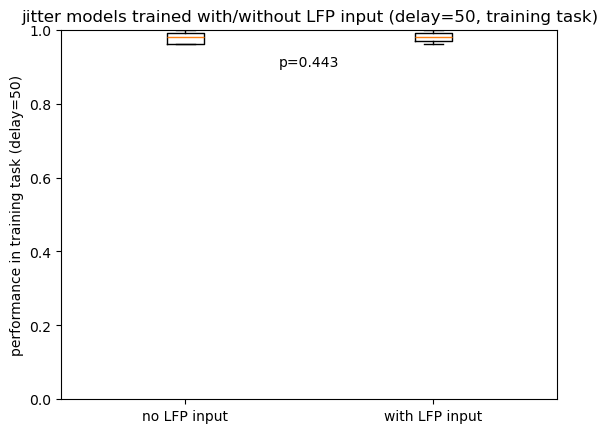

In [4]:
# compare performance in training task (delay=50)

xlfp_perfs = []
for i, model_name in enumerate(xlfp_model_list):
    # print(i, model_name)
    model_path = os.path.join(xlfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    xlfp_perfs.append(model_data['eval_perf_mean'][0][0])
xlfp_perfs = np.array(xlfp_perfs)

lfp_perfs = []
for i, model_name in enumerate(lfp_model_list):
    # print(i, model_name)
    model_path = os.path.join(lfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    lfp_perfs.append(model_data['eval_perf_mean'][0][0])
lfp_perfs = np.array(lfp_perfs)

plt.figure()
plt.boxplot([xlfp_perfs, lfp_perfs], positions=[1, 2])
plt.xticks([1, 2], ['no LFP input', 'with LFP input'])
plt.ylabel('performance in training task (delay=50)')
plt.ylim([0, 1])
plt.title('jitter models trained with/without LFP input (delay=50, training task)')

from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(xlfp_perfs, lfp_perfs)
print('Mann-Whitney U test: stat=%.3f, p=%.3f' % (stat, p))
plt.text(1.5, 0.9, 'p=%.3f' % p, ha='center')
plt.show()

Mann-Whitney U test: stat=156.000, p=0.000


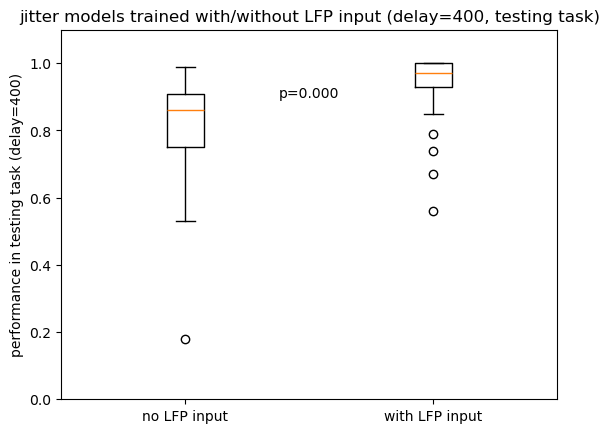

In [5]:
# compare performance in delay=400 task

# delay400
settings = {
        'T': 650, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 400, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [4], # theta
        'power_target_period': 'delay',
        'fs': 200,
        'task': 'xor', # task name
        }

xlfp_perfs_test = []
for i, model_name in enumerate(xlfp_model_list):
    # print(i, model_name)
    output_dir = xlfp_model_dir + '/' + model_name[:-4] + '/'
    with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl'), 'rb') as f:
        bhv_dict = pk.load(f)
    
    xlfp_perfs_test.append(np.mean(bhv_dict["perf"]))
xlfp_perfs_test = np.array(xlfp_perfs_test)

lfp_perfs_test = []
for i, model_name in enumerate(lfp_model_list):
    # print(i, model_name)
    output_dir = lfp_model_dir + '/' + model_name[:-4] + '/'
    with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl'), 'rb') as f:
        bhv_dict = pk.load(f)

    lfp_perfs_test.append(np.mean(bhv_dict["perf"]))
lfp_perfs_test = np.array(lfp_perfs_test)

plt.figure()
plt.boxplot([xlfp_perfs_test, lfp_perfs_test], positions=[1, 2])
plt.xticks([1, 2], ['no LFP input', 'with LFP input'])
plt.ylabel('performance in testing task (delay=400)')
plt.ylim([0, 1.1])
plt.title('jitter models trained with/without LFP input (delay=400, testing task)')

from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(xlfp_perfs_test, lfp_perfs_test)
print('Mann-Whitney U test: stat=%.3f, p=%.3f' % (stat, p))
plt.text(1.5, 0.9, 'p=%.3f' % p, ha='center')

# save as eps
# plt.savefig('model_perf_comparison_delay400.eps', format='eps', dpi=1000)

plt.show()

Mann-Whitney U test: stat=92.000, p=0.004
20 20


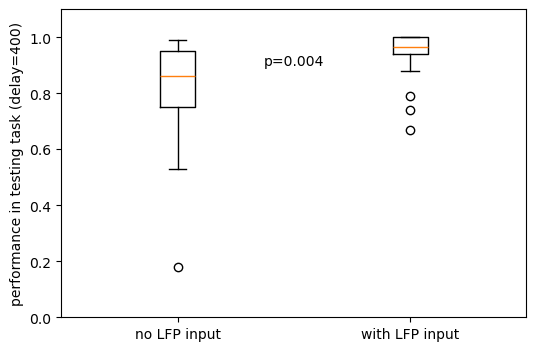

In [6]:
## for abstract — choose 20 for each

i_model = [19, 7, 18, 1, 15, 8, 4, 14, 22, 0, 10, 23, 24, 21, 9, 13, 5, 16, 12, 20]

# compare performance in delay=400 task

# delay400
settings = {
        'T': 650, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 400, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [4], # theta
        'power_target_period': 'delay',
        'fs': 200,
        'task': 'xor', # task name
        }

xlfp_perfs_test = []
for i, model_name in enumerate(xlfp_model_list):
    # print(i, model_name)
    output_dir = xlfp_model_dir + '/' + model_name[:-4] + '/'
    with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl'), 'rb') as f:
        bhv_dict = pk.load(f)
    
    xlfp_perfs_test.append(np.mean(bhv_dict["perf"]))
xlfp_perfs_test = np.array(xlfp_perfs_test)

lfp_perfs_test = []
for i, model_name in enumerate(lfp_model_list):
    # print(i, model_name)
    output_dir = lfp_model_dir + '/' + model_name[:-4] + '/'
    with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl'), 'rb') as f:
        bhv_dict = pk.load(f)

    lfp_perfs_test.append(np.mean(bhv_dict["perf"]))
lfp_perfs_test = np.array(lfp_perfs_test)

# for abstract — choose 20 for each
xlfp_perfs_test = xlfp_perfs_test[i_model]
lfp_perfs_test = lfp_perfs_test[i_model]

plt.figure(figsize=(6,4))
plt.boxplot([xlfp_perfs_test, lfp_perfs_test], positions=[1, 2])
plt.xticks([1, 2], ['no LFP input', 'with LFP input'])
plt.ylabel('performance in testing task (delay=400)')
plt.ylim([0, 1.1])
# plt.title('jitter models trained with/without LFP input (delay=400, testing task)')

from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(xlfp_perfs_test, lfp_perfs_test)
print('Mann-Whitney U test: stat=%.3f, p=%.3f' % (stat, p))
plt.text(1.5, 0.9, 'p=%.3f' % p, ha='center')

print(len(xlfp_perfs_test), len(lfp_perfs_test))

# save as eps
plt.savefig('model_20_perf_comparison_delay400.eps', format='eps', dpi=1000)

plt.show()

## how about models without LFP input to exc or inh neurons

In [7]:
avg_perf_lfp4 = np.zeros((len(lfp_model_list),3))

model_list = lfp_model_list 
model_dir = lfp_model_dir
condns = ['delay400', 'delay400_lfp_exc0', 'delay400_lfp_inh0']

for j, condn in enumerate(condns):
    print(f'Processing condition: {condn}')
    for i, model_name in enumerate(model_list):
            
        # print(f"\nModel: {model_name}")
        output_dir = model_dir + '/' + model_name[:-4] + '/'
        
        # get neural and behavioral data
        bhv_dict = pk.load(open(os.path.join(output_dir, f'bhv_dict_{condn}.pkl'), 'rb'))
        avg_perf_lfp4[i,j] = np.mean(bhv_dict['perf'])

    print(f'{condn} LFP 4Hz avg perf: {np.mean(avg_perf_lfp4[:,j])}, std: {np.std(avg_perf_lfp4[:,j])}')

Processing condition: delay400
delay400 LFP 4Hz avg perf: 0.9316129032258064, std: 0.10531356479713785
Processing condition: delay400_lfp_exc0
delay400_lfp_exc0 LFP 4Hz avg perf: 0.9312903225806451, std: 0.09885610055037056
Processing condition: delay400_lfp_inh0
delay400_lfp_inh0 LFP 4Hz avg perf: 0.5235483870967741, std: 0.16318500063695318


Wilcoxon signed-rank test (intact vs LFP to inh only): stat=136.000, p=0.689
Wilcoxon signed-rank test (intact vs LFP to exc only): stat=10.000, p=0.000


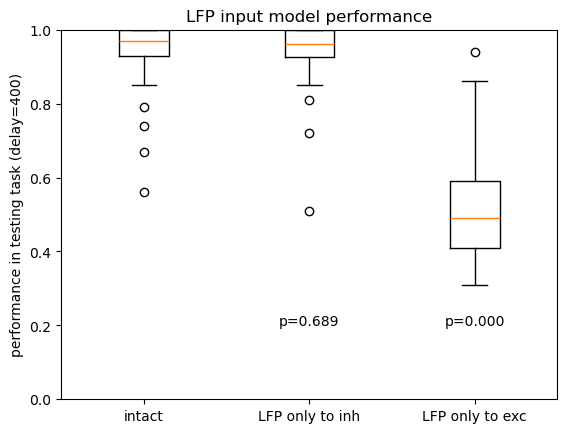

In [8]:
# make boxplot

plt.figure()
plt.boxplot([avg_perf_lfp4[:,0], avg_perf_lfp4[:,1], avg_perf_lfp4[:,2]], positions=[1, 2, 3])
plt.xticks([1, 2, 3], ['intact', 'LFP only to inh', 'LFP only to exc'])
plt.ylabel('performance in testing task (delay=400)')
plt.title('LFP input model performance')

from scipy.stats import wilcoxon
stat, p = wilcoxon(avg_perf_lfp4[:,0], avg_perf_lfp4[:,1])
print('Wilcoxon signed-rank test (intact vs LFP to inh only): stat=%.3f, p=%.3f' % (stat, p))
plt.text(2, 0.2, 'p=%.3f' % p, ha='center')
stat, p = wilcoxon(avg_perf_lfp4[:,0], avg_perf_lfp4[:,2])
print('Wilcoxon signed-rank test (intact vs LFP to exc only): stat=%.3f, p=%.3f' % (stat, p))
plt.text(3, 0.2, 'p=%.3f' % p, ha='center')
plt.ylim([0, 1])

# # save as eps
# plt.savefig('LFPmodel_lesioninput_perf_comparison_delay400.eps', format='eps', dpi=1000)

plt.show()

Wilcoxon signed-rank test (intact vs LFP to inh only): stat=56.500, p=0.551
Wilcoxon signed-rank test (intact vs LFP to exc only): stat=3.000, p=0.000


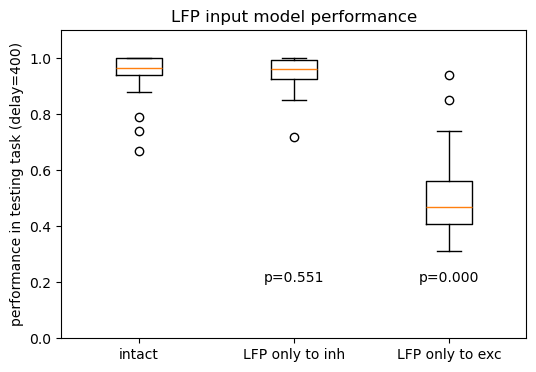

In [11]:
# for abstract — choose 20 models

i_model = [19, 7, 18, 1, 15, 8, 4, 14, 22, 0, 10, 23, 24, 21, 9, 13, 5, 16, 12, 20]

# make boxplot

plt.figure(figsize=(6,4))
plt.boxplot([avg_perf_lfp4[i_model,0], avg_perf_lfp4[i_model,1], avg_perf_lfp4[i_model,2]], positions=[1, 2, 3])
plt.xticks([1, 2, 3], ['intact', 'LFP only to inh', 'LFP only to exc'])
plt.ylabel('performance in testing task (delay=400)')
plt.title('LFP input model performance')

from scipy.stats import wilcoxon
stat, p = wilcoxon(avg_perf_lfp4[i_model,0], avg_perf_lfp4[i_model,1])
print('Wilcoxon signed-rank test (intact vs LFP to inh only): stat=%.3f, p=%.3f' % (stat, p))
plt.text(2, 0.2, 'p=%.3f' % p, ha='center')
stat, p = wilcoxon(avg_perf_lfp4[i_model,0], avg_perf_lfp4[i_model,2])
print('Wilcoxon signed-rank test (intact vs LFP to exc only): stat=%.3f, p=%.3f' % (stat, p))
plt.text(3, 0.2, 'p=%.3f' % p, ha='center')
plt.ylim([0, 1.1])

# save as eps
plt.savefig('LFPmodel_20_lesioninput_perf_comparison_delay400.eps', format='eps', dpi=1000)

plt.show()

In [10]:
stat, p = wilcoxon(avg_perf_lfp4[i_model,0], avg_perf_lfp4[i_model,1])
print('Wilcoxon signed-rank test (intact vs LFP to inh only): stat=%.3f, p=%.3f' % (stat, p))
stat, p = wilcoxon(avg_perf_lfp4[i_model,0], avg_perf_lfp4[i_model,2])
print('Wilcoxon signed-rank test (intact vs LFP to exc only): stat=%.3f, p=%.3f' % (stat, p))
stat, p = wilcoxon(avg_perf_lfp4[i_model,1], avg_perf_lfp4[i_model,2])
print('Wilcoxon signed-rank test (LFP to inh vs LFP to exc only): stat=%.3f, p=%.3f' % (stat, p))

Wilcoxon signed-rank test (intact vs LFP to inh only): stat=56.500, p=0.551
Wilcoxon signed-rank test (intact vs LFP to exc only): stat=3.000, p=0.000
Wilcoxon signed-rank test (LFP to inh vs LFP to exc only): stat=1.000, p=0.000


## 10Hz models

In [2]:
# jitter models trained with 4Hz LFP input

lfp_model_dir = '/home/nuttidalab/Documents/renee/lfp_input_models_wtrain/models/xor/phase/P_rec_0.2_Taus_4.0_25.0'

lfp4_model_list = ld.find_files_keywords(lfp_model_dir, ['Jitter_10_10', '4.0', '.mat'])
lfp10_model_list = ld.find_files_keywords(lfp_model_dir, ['Jitter_10_10', '10.0', '.mat'])
# remove directories
lfp4_model_list = [m.split('/')[-1] for m in lfp4_model_list]
lfp4_model_list.sort()
lfp10_model_list = [m.split('/')[-1] for m in lfp10_model_list]
lfp10_model_list.sort()

print(lfp4_model_list)
print(len(lfp4_model_list))
print(lfp10_model_list)
print(len(lfp10_model_list))


['Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134255.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134527.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134559.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_134903.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_135100.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_135226.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_135856.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140038.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140105.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_140736.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_141248.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_19_141842.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121450.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121653.mat', 'Task_xor_N_200_Jitter_10_10_LFPdelay_4.0_2025_09_26_121726.mat', 'Task_xor

Mann-Whitney U test: stat=151.000, p=0.577


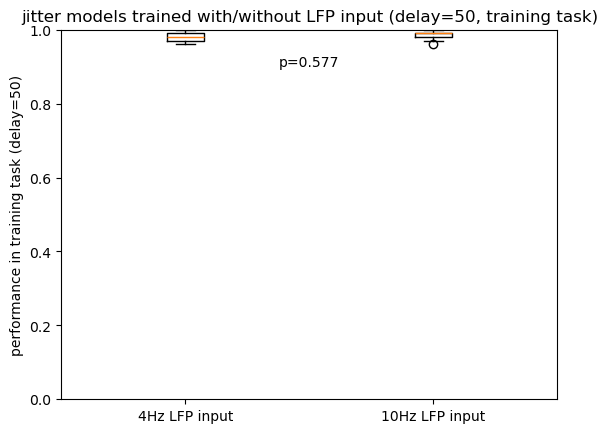

In [3]:
# compare performance in training task (delay=50)

lfp4_perfs = []
for i, model_name in enumerate(lfp4_model_list):
    # print(i, model_name)
    model_path = os.path.join(lfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    lfp4_perfs.append(model_data['eval_perf_mean'][0][0])
lfp4_perfs = np.array(lfp4_perfs)

lfp10_perfs = []
for i, model_name in enumerate(lfp10_model_list):
    # print(i, model_name)
    model_path = os.path.join(lfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    lfp10_perfs.append(model_data['eval_perf_mean'][0][0])
lfp10_perfs = np.array(lfp10_perfs)

plt.figure()
plt.boxplot([lfp4_perfs, lfp10_perfs], positions=[1, 2])
plt.xticks([1, 2], ['4Hz LFP input', '10Hz LFP input'])
plt.ylabel('performance in training task (delay=50)')
plt.ylim([0, 1])
plt.title('jitter models trained with/without LFP input (delay=50, training task)')

from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(lfp4_perfs, lfp10_perfs)
print('Mann-Whitney U test: stat=%.3f, p=%.3f' % (stat, p))
plt.text(1.5, 0.9, 'p=%.3f' % p, ha='center')
plt.show()